# core

> Read, search, preview, and edit PDFs with pypdfium2

In [ ]:
#| default_exp core

fastpdfium is a small ergonomic layer over [pypdfium2](https://pypdfium2.readthedocs.io/) for working with PDFs interactively -- in Jupyter, solveit, or an AI-driven kernel. The design rule: reach for *text* first (cheap, precise), and for *pixels* when layout matters. Search is content-based: a hit knows its matched text and surroundings, and can show itself highlighted on the rendered page.

pypdfium2 wraps PDFium, the permissively-licensed PDF engine from Chrome, so fastpdfium is plain Apache-2.0.

In [ ]:
#| export
from fastcore.utils import *
from fastcore.meta import delegates
from PIL import Image, ImageDraw
from pypdfium2 import raw

import ctypes, io, pypdfium2 as pdfium

In [ ]:
#| export
_all_ = ['pdfium']

In [ ]:
from fastcore.test import *

## Pages know their number

pypdfium2 pages don't record their index, but page-tagged text and search results need it. We wrap the two ways a page is loaded so every page carries a `number` (and `new_page` gains an A4 default while we're at it).

In [ ]:
#| export
if not hasattr(pdfium.PdfDocument, '_get_page'):
    pdfium.PdfDocument._get_page,pdfium.PdfDocument._new_page = pdfium.PdfDocument.get_page,pdfium.PdfDocument.new_page

@patch
def get_page(self:pdfium.PdfDocument, index):
    "Load page `index`, remembering it as `page.number`"
    pg = self._get_page(index)
    pg.number = index
    return pg

@patch
def new_page(self:pdfium.PdfDocument, width=595, height=842, index=None):
    "Append (or insert at `index`) a blank `width`x`height` point page, numbered like `get_page`"
    pg = self._new_page(width, height, index)
    pg.number = len(self)-1 if index is None else index
    return pg

In [ ]:
d = pdfium.PdfDocument.new()
pg = d.new_page()
test_eq(pg.number, 0)
test_eq(pg.get_size(), (595, 842))
test_eq(d[0].number, 0)

## Creating PDFs

pypdfium2's helpers stop at page shuffling, but PDFium's raw API can author content. These helpers cover the common needs: text, boxes, and images. Positions are in points from the *top-left* of the page, matching how you look at a rendered preview; the y-flip to PDF's bottom-left convention happens inside.

In [ ]:
#| export
@patch
def insert_text(
    self:pdfium.PdfPage,
    text, # Text to insert; newlines start new lines
    x=72, # Baseline start x, in points from the left
    y=72, # Baseline start y, in points from the top
    size=12, # Font size in points
    font='Helvetica', # Standard PDF font name
):
    "Insert `text` on the page at `x`,`y`"
    f = raw.FPDFText_LoadStandardFont(self.pdf.raw, font.encode())
    for j,line in enumerate(text.split('\n')):
        t = raw.FPDFPageObj_CreateTextObj(self.pdf.raw, f, size)
        buf = ctypes.create_string_buffer(line.encode('utf-16-le')+b'\x00\x00')
        raw.FPDFText_SetText(t, ctypes.cast(buf, ctypes.POINTER(ctypes.c_ushort)))
        raw.FPDFPageObj_Transform(t, 1, 0, 0, 1, x, self.get_height()-y-1.2*size*j)
        self.insert_obj(pdfium.PdfObject(t))
    self.gen_content()

In [ ]:
pg.insert_text('Hello\nPDF world', 72, 100, size=14)
test_eq(pg.get_textpage().get_text_range(), 'Hello\r\nPDF world')

In [ ]:
#| export
@patch
def draw_rect(
    self:pdfium.PdfPage,
    x0, y0, x1, y1, # Corners, in points from the top-left
    stroke=(255,0,0,255), # Stroke RGBA, 0-255 each (None for none)
    fill=None, # Fill RGBA (None for none)
    width=1, # Stroke width in points
):
    "Draw a rectangle from `x0`,`y0` to `x1`,`y1`"
    rc = raw.FPDFPageObj_CreateNewRect(x0, self.get_height()-y1, x1-x0, y1-y0)
    if stroke:
        raw.FPDFPageObj_SetStrokeColor(rc, *stroke)
        raw.FPDFPageObj_SetStrokeWidth(rc, width)
    if fill: raw.FPDFPageObj_SetFillColor(rc, *fill)
    raw.FPDFPath_SetDrawMode(rc, 1 if fill else 0, bool(stroke))
    self.insert_obj(pdfium.PdfObject(rc))
    self.gen_content()

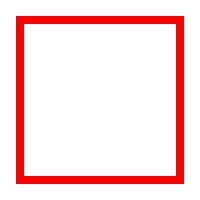

In [ ]:
p2 = d.new_page(100, 100)
p2.draw_rect(10, 10, 90, 90, width=4)
test_eq(p2.render(scale=1).to_pil().getpixel((50, 10))[:3], (255, 0, 0))
p2.render(scale=2).to_pil()

In [ ]:
#| export
@patch
def insert_image(
    self:pdfium.PdfPage,
    img, # PIL image, or a path PIL can open
    x=72, # Left edge of the placed image, in points
    y=72, # Top edge of the placed image, in points
    w=None, # Width in points (default: pixel size; aspect kept if only one given)
    h=None, # Height in points
):
    "Place `img` at `x`,`y` (stored as JPEG)"
    if not isinstance(img, Image.Image): img = Image.open(img)
    if w is None and h is None: w,h = img.size
    elif w is None: w = h*img.width/img.height
    elif h is None: h = w*img.height/img.width
    buf = io.BytesIO()
    img.convert('RGB').save(buf, 'JPEG', quality=95)
    buf.seek(0)
    o = pdfium.PdfImage.new(self.pdf)
    o.load_jpeg(buf)
    o.set_matrix(pdfium.PdfMatrix(w, 0, 0, h, x, self.get_height()-y-h))
    self.insert_obj(o)
    self.gen_content()

In [ ]:
p3 = d.new_page(100, 100)
p3.insert_image(Image.new('RGB', (40, 30), 'orange'), 30, 40)
test_close(p3.render(scale=1).to_pil().getpixel((50, 55))[:3], (255, 165, 0), eps=20)

Serializing to bytes rounds out authoring: build a document in memory and hand it anywhere that expects PDF data.

In [ ]:
#| export
@patch
def tobytes(self:pdfium.PdfDocument)->bytes:
    "The document serialized as PDF bytes"
    buf = io.BytesIO()
    self.save(buf)
    return buf.getvalue()

In [ ]:
b = d.tobytes()
test_eq(b[:5], b'%PDF-')
test_eq(len(pdfium.PdfDocument(b)), 3)

## A sample document

With authoring in hand, the rest of the notebook reads a small two-page PDF built right here, so the demos are deterministic and self-contained.

In [ ]:
smpl = pdfium.PdfDocument.new()
for lines in (['CERTIFICATE OF INCORPORATION','OF','EXAMPLE CORP','a Delaware corporation'],
              ['ARTICLE ONE','The name of the corporation is','Example Corp']):
    smpl.new_page().insert_text('\n'.join(lines), 72, 92, size=14)
pg0 = smpl[0]

## Text

Most questions about a PDF are answered by its text. `Page.text` normalizes PDFium's CRLF line breaks; `Document.text` gives the whole document (or chosen pages) in one string, with page markers so line references stay grounded.

In [ ]:
#| export
@patch
def text(self:pdfium.PdfPage)->str:
    "Plain text of the page"
    return self.get_textpage().get_text_range().replace('\r\n', '\n')

In [ ]:
test_eq(pg0.text(), 'CERTIFICATE OF INCORPORATION\nOF\nEXAMPLE CORP\na Delaware corporation')

In [ ]:
#| export
@patch
def text(self:pdfium.PdfDocument, pages=None)->str:
    "Plain text of `pages` (default: all), with `--- page N ---` separators"
    idxs = range(len(self)) if pages is None else pages
    return '\n'.join(f'--- page {i} ---\n{self[i].text().rstrip()}' for i in idxs)

In [ ]:
t = smpl.text()
assert 'CERTIFICATE OF INCORPORATION' in t and '--- page 1 ---' in t
assert 'ARTICLE ONE' not in smpl.text(pages=[0])
print(t)

--- page 0 ---
CERTIFICATE OF INCORPORATION
OF
EXAMPLE CORP
a Delaware corporation
--- page 1 ---
ARTICLE ONE
The name of the corporation is
Example Corp


## Search

Search is content-based, PDFium's way: a `Match` is a range of characters on a page, so it knows its matched text and can show the text around it -- which is what an LLM (or a person) actually wants from a search hit. Geometry stays internal, used only to draw highlights.

In [ ]:
#| export
class Match:
    "A search hit: chars `i` to `i+n` on `page`"
    def __init__(self, page, i, n, tp=None):
        store_attr('page,i,n')
        self.tp = tp or page.get_textpage()
    @property
    def text(self):
        "The matched text"
        return self.tp.get_text_range(self.i, self.n)
    def ctx(self, chars=40)->str:
        "The match marked with `**`, plus up to `chars` of surrounding text each side"
        s,e = max(0, self.i-chars), min(self.tp.count_chars(), self.i+self.n+chars)
        pre,post = self.tp.get_text_range(s, self.i-s), self.tp.get_text_range(self.i+self.n, e-self.i-self.n)
        return re.sub(r'[\r\n]+', ' ', f'{pre}**{self.text}**{post}')
    def rects(self):
        "Bounding boxes of the matched chars, in PDF (bottom-left origin) coords"
        return [self.tp.get_rect(k) for k in range(self.tp.count_rects(self.i, self.n))]
    def __repr__(self): return f'page {self.page.number}: {self.ctx()}'

@patch
def search(
    self:pdfium.PdfPage,
    q, # Text to search for
    match_case=False, # Case-sensitive?
    match_whole_word=False, # Whole words only?
    consecutive=False, # Allow overlapping matches?
)->list:
    "All `Match`es for `q` on this page"
    tp = self.get_textpage()
    srch = tp.search(q, match_case=match_case, match_whole_word=match_whole_word, consecutive=consecutive)
    res = []
    while (m := srch.get_next()) is not None: res.append(Match(self, *m, tp=tp))
    return res

@patch
@delegates(pdfium.PdfPage.search)
def search(self:pdfium.PdfDocument, q, **kwargs)->list:
    "All `Match`es for `q` across the document"
    return [m for p in self for m in p.search(q, **kwargs)]

In [ ]:
ms = smpl.search('corporation')
test_eq([m.page.number for m in ms], [0, 0, 1])
test_eq(ms[1].text, 'corporation')
test_eq(smpl.search('nonexistent'), [])
ms

[page 0: CERTIFICATE OF IN**CORPORATION** OF EXAMPLE CORP a Delaware corporati,
 page 0: RPORATION OF EXAMPLE CORP a Delaware **corporation**,
 page 1: ARTICLE ONE The name of the **corporation** is Example Corp]

The match options come straight from PDFium, and `ctx` gives an LLM-ready snippet: the hit marked inline, with its surroundings.

In [ ]:
test_eq(len(smpl.search('CORPORATION', match_case=True)), 1)
assert '**corporation**' in ms[1].ctx()
ms[1].ctx(chars=12)

' a Delaware **corporation**'

## Preview

`Page.preview` renders to a PIL image at `dpi` (default 150: a page is ~1650px on the long edge, comfortably readable for vision models while staying cheap). Pass a query `q` and the matches are outlined in red; add `crop=True` to cut down to just the matched region plus a `margin` of context. PDFium's hit boxes hug the glyphs, so highlights get a couple points of breathing room.

In [ ]:
#| export
@patch
def preview(
    self:pdfium.PdfPage,
    q=None, # Text whose matches to highlight
    dpi=150, # Render resolution
    crop=False, # Crop to the matched region?
    margin=24, # Points of context around a crop
):
    "Render to a PIL image, highlighting and optionally cropping to `q`'s matches"
    sc = dpi/72
    img = self.render(scale=sc).to_pil()
    if not q: return img
    ms = self.search(q)
    if not ms: raise ValueError(f'{q!r} not found on page {self.number}')
    h = self.get_height()
    rects = [rc for m in ms for rc in m.rects()]
    draw = ImageDraw.Draw(img)
    for l,b,r_,t in rects: draw.rectangle([(l-2)*sc, (h-t-2)*sc, (r_+2)*sc, (h-b+2)*sc], outline='red', width=max(1, round(dpi/50)))
    if crop:
        l,b = min(o[0] for o in rects)-margin, min(o[1] for o in rects)-margin
        r_,t = max(o[2] for o in rects)+margin, max(o[3] for o in rects)+margin
        img = img.crop((max(0, l*sc), max(0, (h-t)*sc), min(img.width, r_*sc), min(img.height, (h-b)*sc)))
    return img

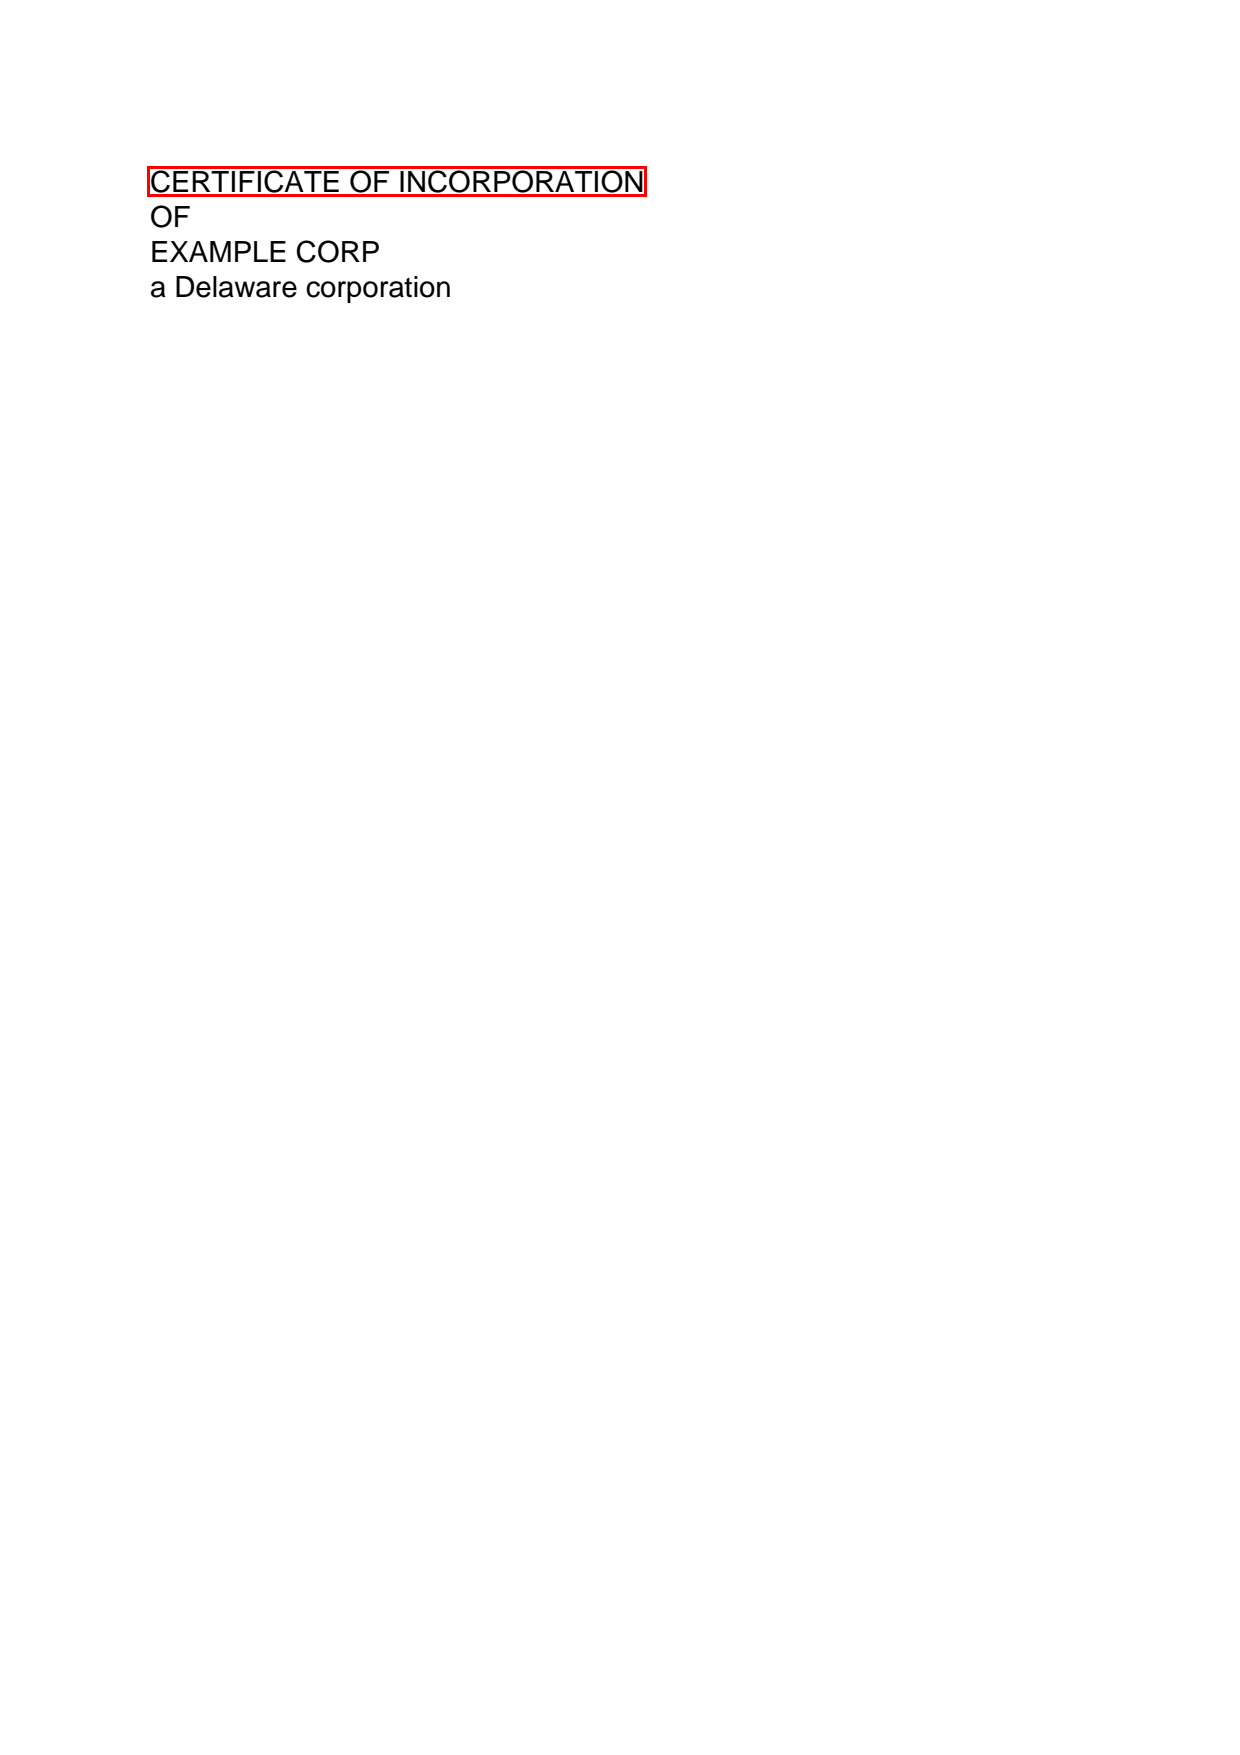

In [ ]:
im = pg0.preview()
assert abs(im.width - 595*150/72) <= 1 and abs(im.height - 842*150/72) <= 1
test_fail(lambda: pg0.preview('missing text'), contains='not found')
pg0.preview('CERTIFICATE OF INCORPORATION')

`crop=True` renders just the neighborhood of the hits -- the cheap way to show a vision model exactly the region that matters:

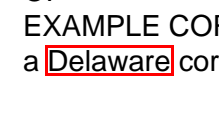

In [ ]:
pg0.preview('Delaware', crop=True)

### Pages display themselves

With a `_repr_png_`, a bare `Page` expression renders visually in any rich frontend.

In [ ]:
#| export
@patch
def _repr_png_(self:pdfium.PdfPage): return self.preview()._repr_png_()

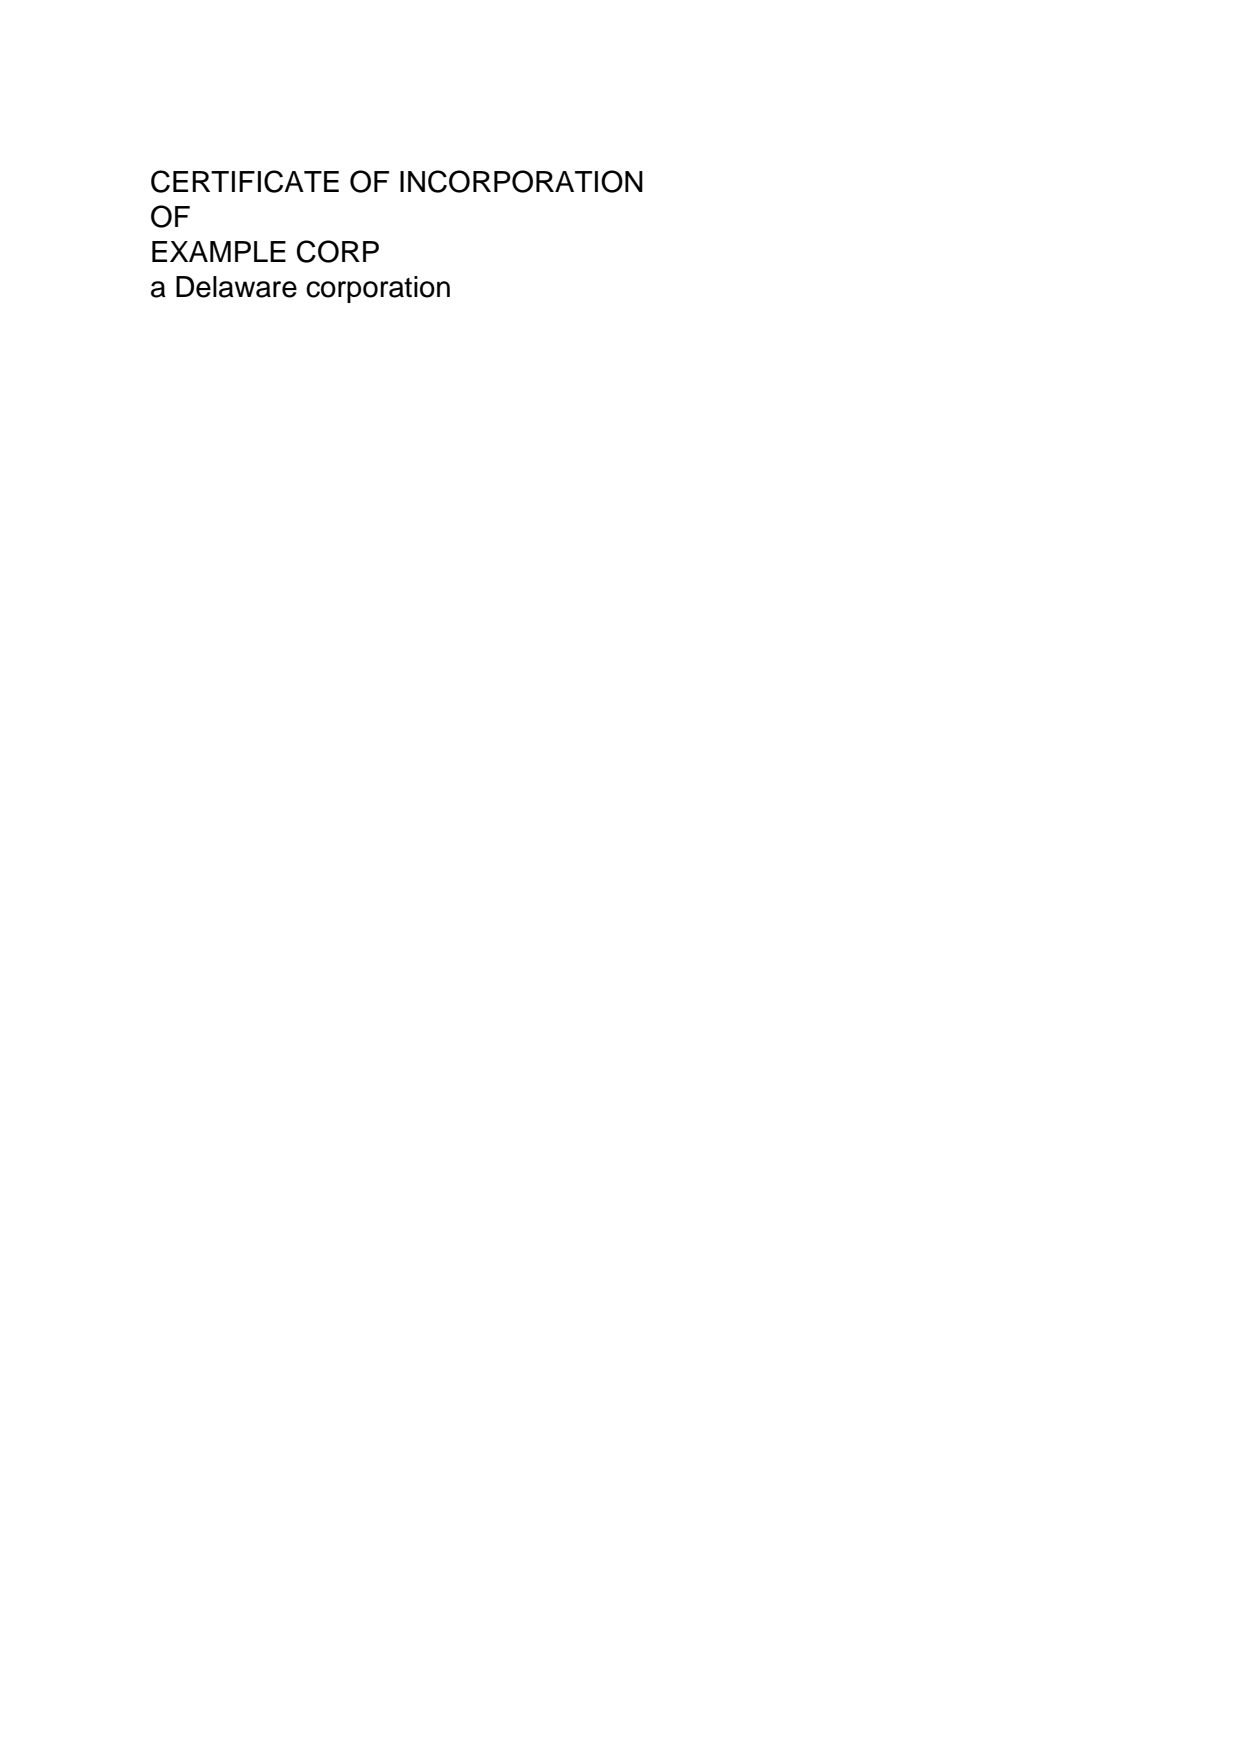

In [ ]:
assert pg0._repr_png_()[:8] == b'\x89PNG\r\n\x1a\n'
pg0

The idioms compose: search the document, read a match in context, then look at it on the page.

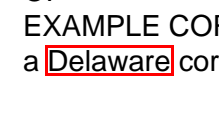

In [ ]:
m = smpl.search('Delaware')[0]
m.page.preview('Delaware', crop=True)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()